In [82]:
from langgraph.graph import StateGraph , START, END
from typing import TypedDict
from IPython.display import Image

In [83]:
# Define your state:
class Bmi_State(TypedDict):
  weight_kg:float
  height_m:float
  bmi:float
  category:str


In [84]:
# define node function:
def bmi_calcuate(state:Bmi_State) -> Bmi_State:
  weight = state["weight_kg"]
  height = state["height_m"]
  bmi = weight / height**2

  state["bmi"] = round(bmi , 2)
  return state

def fitness_calculate(state:Bmi_State) -> Bmi_State:
  if state["bmi"] < 18.5:
    state["category"] = "Underweight"
  elif state["bmi"] < 25:
    state["category"] = "Normal"
  elif state["bmi"] < 30:
    state["category"] = "Overweight"
  else:
    state["category"] = "Obese"
  return state


In [85]:
# Register your Graph:
graph = StateGraph(Bmi_State)

# add nodes to your graph.
graph.add_node("bmi_cal" , bmi_calcuate)
graph.add_node("check_fitness" , fitness_calculate)

# add edges to your graph.
graph.add_edge(START , "bmi_cal")
graph.add_edge("bmi_cal" , "check_fitness")
graph.add_edge("check_fitness" , END)

# comile your graph.
workflow = graph.compile()

# execute the graph.
num1 = float(input("Enter weight in kg: "))
num2 = float(input("Enter height in m:"))

input_data = {"weight_kg":num1 , "height_m" :num2}

output = workflow.invoke(input_data)
print(output)

Enter weight in kg: 30
Enter height in m:3.3
{'weight_kg': 30.0, 'height_m': 3.3, 'bmi': 2.75, 'category': 'Underweight'}


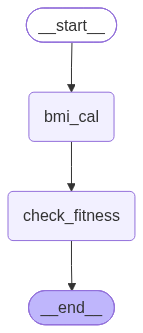

In [86]:
Image(workflow.get_graph().draw_mermaid_png())